<div style="width:100%;height:6px;background-color:green"> </div>

## Feature Engineering for Data Science

### PCA (Principal Component Analysis)
- Image compression
- Removal of uncorrelated phenomena (irregularities) in the image
- Methods for anomaly detection in the image
  - Localization of uncorrelated phenomena by filtering correlated phenomena using PCA (X-Xpca => occurrence of anomalies in the image)
  - Localization of uncorrelated phenomena by filtering correlated phenomena using PCA (Xpca => occurrence of anomalies in the image)

<br>

<div style="width:100%;height:6px;background-color:green"> </div>

### Note (SVD ... Singular Value Decomposition)

The SVD method (decomposition) is analogous and is used for the same purposes as SVD in signal and image processing. SVD is recommended for sparse matrices (images), while PCA is recommended in the opposite cases.



<div style="width:100%;height:6px;background-color:green"> </div>

### PCA

#### Compression - Reducing the number of columns in matrix/image $\textbf{X}$

Image

$$
\begin{align}
\textbf{X} &=
\begin{bmatrix}
 & \textbf{x}_1 & \textbf{x}_2 & \cdots & \textbf{x}_M
\end{bmatrix}\\ \\
&=
\begin{bmatrix}
x_1(k=1) & x_2(k=1) & \cdots & x_M(k=1) \\
x_1(k=2) & x_2(k=2) & \cdots & x_M(k=2) \\
\vdots & \vdots & \cdots & \vdots \\
x_1(k=N) & x_2(k=N) & \cdots & x_M(k=N) \\
\end{bmatrix} \ ... N \times M
\end{align}
$$

Column Centering (typically Z-Score here)

$$ \textbf{x}_i\leftarrow\large\frac{\textbf{x}_i-\overline{\textbf{x}_i}}{\large\sigma_i}; \normalsize i=1\dots M $$

Covariance Matrix (matrix of correlation coefficients between columns of $\textbf{X}$)

$$\textbf{covX}=\dfrac{1}{N}\textbf{X}^T\cdot \textbf{X}.$$

Eigenvalues and Eigenvectors

$$d, \textbf{V}=\text{eig}(\textbf{covX}),$$
where
$$\textbf{V}=\begin{bmatrix}
\textbf{v}_1 &\textbf{v}_2  & ... & \textbf{v}_M
\end{bmatrix}
\text{ where }
\textbf{v}_i ... M\times 1.$$

In the columns of $\textbf{V}_{PCA}$ are the eigenvectors of the covariance matrix.

We choose the number of most significant eigenvectors $m << M$.

Column Compression:

$$\textbf{X}_{compressed}=\textbf{X}\cdot \textbf{V}_{[:,1:m]}  \ ... N \times m .$$

Decompression

$$\textbf{X}_{PCA}=(\textbf{X}\cdot \textbf{V}_{[:,1:m]})\cdot \textbf{V}_{[:,1:m]}^T  \ ... N \times M, $$

where $\textbf{V}_{[:,1:m]}^T$ is the pseudoinverse.

#### Then, transpose the matrix $\textbf{X}_{PCA}$, and similarly compress the original image through rows...


<div style="width:100%;height:6px;background-color:green"> </div>

PCA pro odfiltrování nekorelovaných anomálií pomocí $n$ a $m$ nejvýznamnějších vlastních vektorů kovarianční matice (zachovávají se lineárně korelované=opakující se jevy).


<img src="./img/PCA_explain_1.PNG">

<div style="width:100%;height:6px;background-color:green"> </div>

Or vice versa: PCA for filtering correlated phenomena (for compression and decompression, we do not use $n$ and $m$ most significant eigenvectors of the covariance matrix).

<img src="./img/PCA_explain_2.PNG">


<div style="width:100%;height:6px;background-color:green"> </div>

Similarly:

<img src="./img/PCA_explain_3.PNG">

<img src="./img/PCA_explain_4.PNG">

<div style="width:100%;height:6px;background-color:green"> </div>


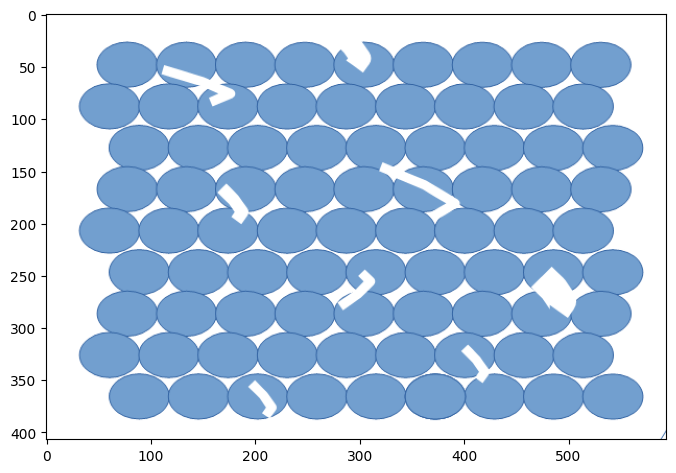

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import PIL as pil
img1="./img/regular_patttern_with_perturb.png"


im1 = pil.Image.open(img1)


plt.figure(figsize=(8,8))
plt.imshow(im1)
plt.show()

In [ ]:
from scipy import signal
im1=np.mean(im1,2)  # gray img, 2-D matrix,...X

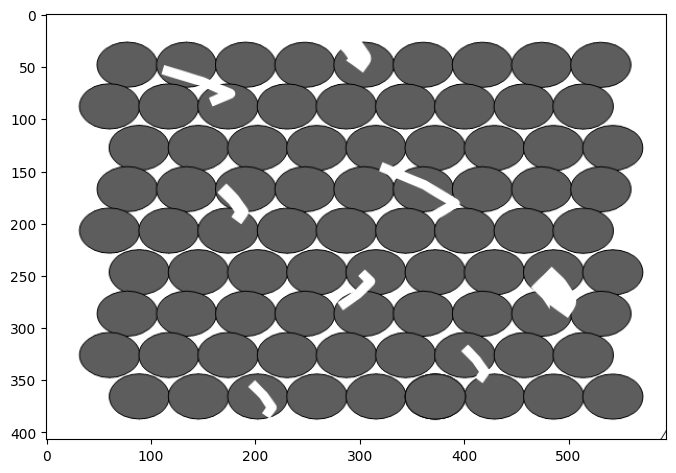

im1 is now matrix, i.e. <class 'numpy.ndarray'> (407, 594)


In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(im1,cmap='gray')
plt.show()

print("im1 is now matrix, i.e.", type(im1), im1.shape)


<div style="width:100%;height:9px;background-color:green"> </div>

### Localization of uncorrelated events by filtering correlated events using PCA (X-Xpca => occurrence of anomalies in the image)
i.e. filtering correlated events => occurrence of anomalies


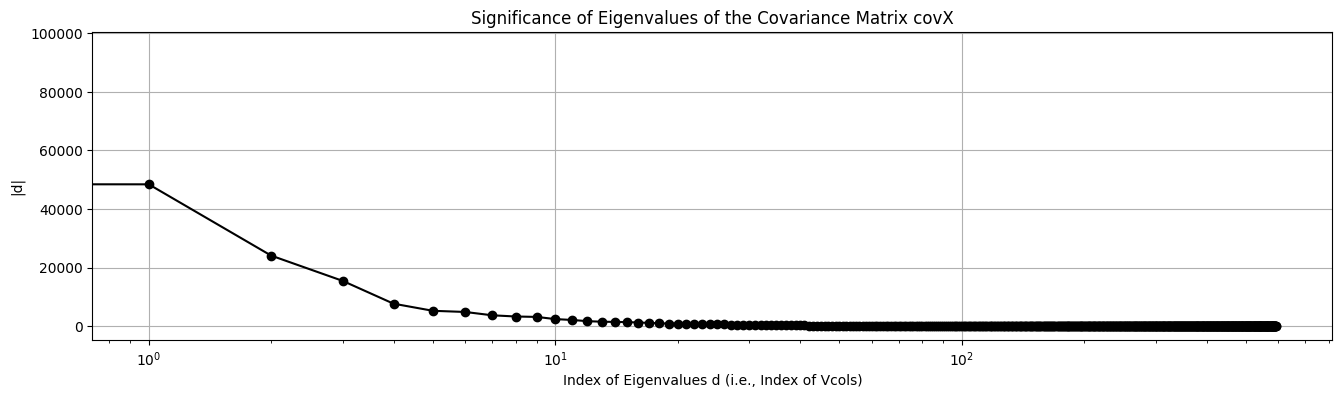

In [ ]:
X = im1.copy()
X = (X - np.mean(X)) / np.std(X)

covX = np.dot(X.T, X)  # Covariance matrix (M x M)

d, Vcols = np.linalg.eig(covX)  # Eigenvalues and eigenvectors

plt.figure(figsize=(16, 4))
plt.title("Significance of Eigenvalues of the Covariance Matrix covX")
plt.semilogx(abs(d), '-ok')
plt.ylabel('|d|')
plt.xlabel('Index of Eigenvalues d (i.e., Index of Vcols)')
plt.grid()
plt.show()



<div style="width:100%;height:6px;background-color:green"> </div>

## Compression using PCA

### (And its use for the localization of anomalous events by filtering uncorrelated events using PCA)

i.e., residuals = original - image without uncorrelated events => occurrence of anomalies



<div style="width:100%;height:3px;background-color:green"> </div>

### Compression through Columns and Subsequently through Rows

#### Through Columns: I choose $m<<M$ most significant eigenvectors, i.e., $n$ columns $\textbf{V}_{cols}$ for which the eigenvalues $d$ are the largest (see the previous graph) (the compressed image will have $N$ rows and $m$ columns).


In [ ]:
print("X ... N x M =",X.shape)
m=6
print("choosing m=",m)

Xcols=np.dot(X,Vcols[:,:m])  # compressed na m sloupcu

print("Xcols ... N x m =",Xcols.shape)


X ... N x M = (407, 594)
choosing m= 6
Xcols ... N x m = (407, 6)


#### Along the rows: I select $n<<N$ most significant eigenvectors, i.e., $n$ columns $\textbf{V}_{rows}$ for which the eigenvalues $d$ are the largest (see the following graph).


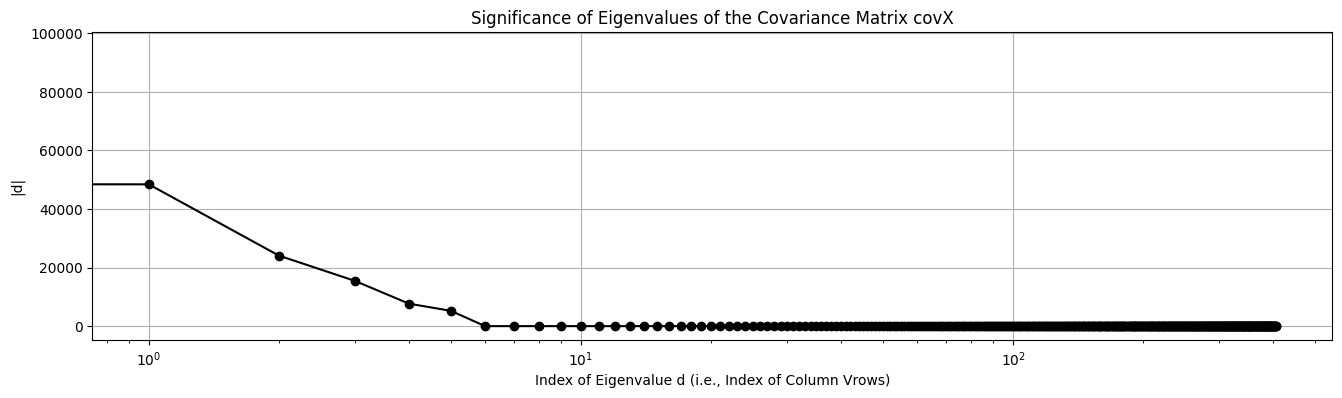

In [ ]:
# Compression along the rows
Xrows = Xcols.T
covX = np.dot(Xrows.T, Xrows)  # Covariance matrix (N x N)
d, Vrows = np.linalg.eig(covX)

plt.figure(figsize=(16, 4))
plt.title("Significance of Eigenvalues of the Covariance Matrix covX")
plt.semilogx(abs(d), '-ok')
plt.ylabel('|d|')
plt.xlabel('Index of Eigenvalue d (i.e., Index of Column Vrows)')
plt.grid()
plt.show()


Xrows ... n x M = (6, 407)
Choice of n = 6
Xcompressed ... n x m = (6, 6)


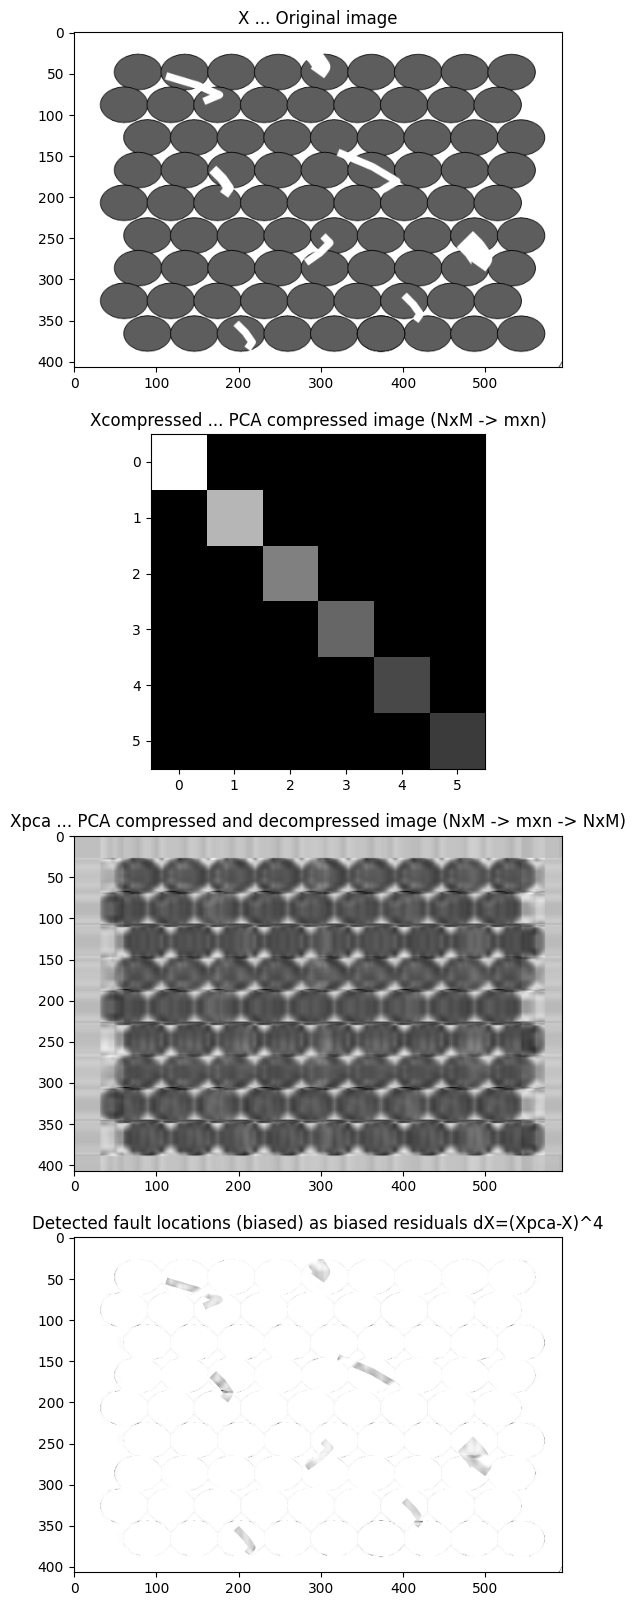

In [ ]:
print("Xrows ... n x M =", Xrows.shape)
n = 6
print("Choice of n =", n)
Xcompressed = np.dot(Xrows, Vrows[:, :n])  # Compressed image with n rows and m columns
print("Xcompressed ... n x m =", Xcompressed.shape)

### Decompression - retaining only correlated events (the degree of correlation depends on the choice of m and n)

Xpca_rows = np.dot(Xcompressed, Vrows[:, :n].T)
Xpca_cols = Xpca_rows.T
Xpca = np.dot(Xpca_cols, Vcols[:, :m].T)

Xpca = np.real(Xpca)

plt.figure(figsize=(16, 20))
plt.subplot(411)
plt.imshow(X, cmap='gray')
plt.title("X ... Original image")
plt.subplot(412)
plt.imshow(abs(Xcompressed), cmap='gray')
plt.title("Xcompressed ... PCA compressed image (NxM -> mxn)")
plt.subplot(413)
plt.imshow(Xpca, cmap='gray')
plt.title("Xpca ... PCA compressed and decompressed image (NxM -> mxn -> NxM)")
plt.subplot(414)
dX = (Xpca - X) ** 4  # Thresholding (enhancing the difference between white and black), using powers of 2, 4, 6, 8
plt.imshow(-dX, cmap='gray')
plt.title("Detected fault locations (biased) as biased residuals dX=(Xpca-X)^4")
plt.show()


In [ ]:
Xpca.shape

(407, 594)

<div style="width:100%;height:9px;background-color:green"> </div>

### Localization of uncorrelated events by filtering correlated events using PCA (Xpca => occurrence of anomalies in the image)
i.e. filtering correlated events => occurrence of anomalies


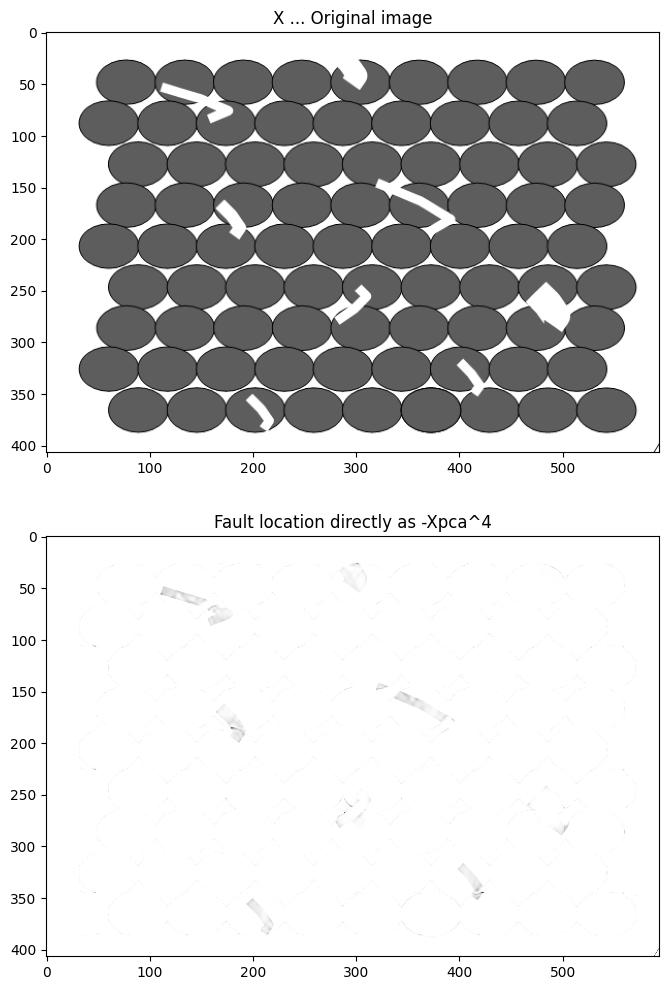

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import PIL as pil
from scipy import signal

# Path to the image
img1="./img/regular_patttern_with_perturb.png"
im1 = pil.Image.open(img1)
im1 = np.mean(im1, 2)  # Image as a single matrix

# Copy and normalize the image
X = im1.copy()
X = (X - np.mean(X)) / np.std(X)

# Calculate the covariance matrix (M x M)
covX = np.dot(X.T, X)

# Eigenvalues and eigenvectors
d, Vcols = np.linalg.eig(covX)

# Define the value 'm'
m = 6

# Project the data onto the first 'm' columns of Vcols
Xcols = np.dot(X, Vcols[:, m:])

# Project the data along the columns to get 'Xrows'
Xrows = Xcols.T

# Calculate the covariance matrix (N x N) for 'Xrows'
covX = np.dot(Xrows.T, Xrows)

# Eigenvalues and eigenvectors for 'Xrows'
d, Vrows = np.linalg.eig(covX)

# Define the value 'n'
n = 6

# Compress the image to 'n' rows and 'm' columns
Xcompressed = np.dot(Xrows, Vrows[:, n:])

# Perform the decompression
Xpca_rows = np.dot(Xcompressed, Vrows[:, n:].T)
Xpca_cols = Xpca_rows.T
Xpca = np.dot(Xpca_cols, Vcols[:, m:].T)
Xpca = np.real(Xpca)

# Create a figure for visualization
plt.figure(figsize=(10, 12))
plt.subplot(211)
plt.title("X ... Original image")
plt.imshow(X, cmap='gray')
plt.subplot(212)
plt.imshow(-Xpca**4, cmap='gray')
plt.title("Fault location directly as -Xpca^4")
plt.show()


<div style="width:100%;height:6px;background-color:green"> </div>

#### Tasks:

<b>T3.1</b>  Try PCA on your own image for the detection of uncorrelated anomalies in the image (or noise).<b style="color:blue;">[0.3 Points]</b>

<b>T3.2</b>  Explore the influence of the choice of the number of eigenvectors on the quality of detection.<b style="color:blue;">[0.3 Points]</b>

<b>T3.3</b>  Create concise documentation for the solution, code, and the achieved results (3-5 pages of A4). Properly cite the used sources!<b style="color:blue;">[0.6 Points]</b>

<br>


 T3.1) Try PCA on your own image for the detection of uncorrelated anomalies in the image (or noise)

T3.2) Explore the influence of the choice of the number of eigenvectors on the quality of detection.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


X ... N x M = (1024, 1024)


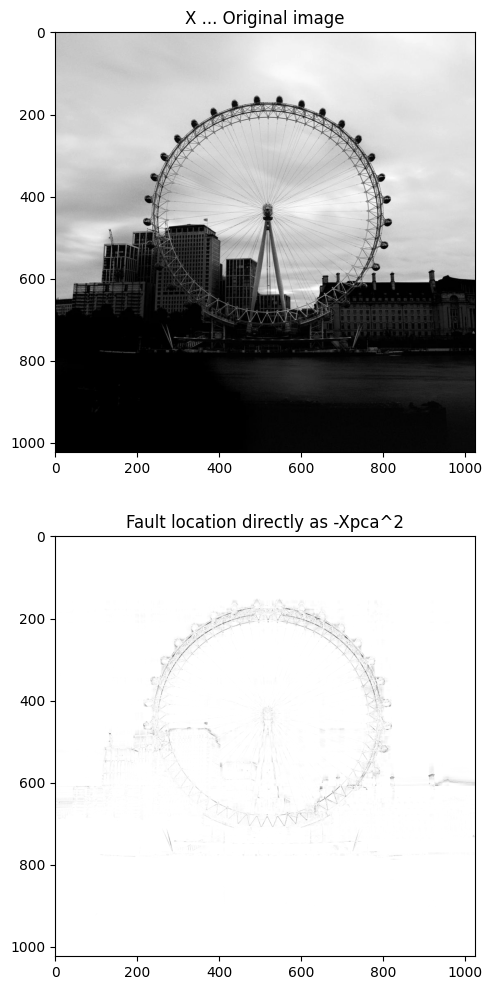

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import PIL as pil
from PIL import Image


'''img1="/content/drive/MyDrive/Colab Notebooks/image1.webp.jpg"

im1 = pil.Image.open(img1)'''


# original image
img1 = "/content/drive/MyDrive/Colab Notebooks/image1.webp.jpg"
im1 = Image.open(img1)

# Resize the image to 1024x1024
resized_image = im1.resize((1024, 1024), Image.Resampling.LANCZOS)

# Save or display the resized image
resized_image.save("/content/drive/MyDrive/Colab Notebooks/image1.webp.jpg")  # Save the resized image
resized_image.show()  # Display the resized image
im1 = resized_image

from scipy import signal
im1=np.mean(im1,2)  # gray img, 2-D matrix,...X

X = im1.copy()
X = (X - np.mean(X)) / np.std(X)

# Calculate the covariance matrix (M x M)
covX = np.dot(X.T, X)
# Eigenvalues and eigenvectors
d, Vcols = np.linalg.eig(covX)

print("X ... N x M =",X.shape)

m = 8

# Project the data onto the first 'm' columns of Vcols
Xcols = np.dot(X, Vcols[:, m:])

# Project the data along the columns to get 'Xrows'
Xrows = Xcols.T

# Calculate the covariance matrix (N x N) for 'Xrows'
covX = np.dot(Xrows.T, Xrows)

# Eigenvalues and eigenvectors for 'Xrows'
d, Vrows = np.linalg.eig(covX)

# Define the value 'n'
n = 8

# Compress the image to 'n' rows and 'm' columns
Xcompressed = np.dot(Xrows, Vrows[:, n:])

# Perform the decompression
Xpca_rows = np.dot(Xcompressed, Vrows[:, n:].T)
Xpca_cols = Xpca_rows.T
Xpca = np.dot(Xpca_cols, Vcols[:, m:].T)
Xpca = np.real(Xpca)

# Create a figure for visualization
plt.figure(figsize=(10, 12))
plt.subplot(211)
plt.title("X ... Original image")
plt.imshow(X, cmap='gray')
plt.subplot(212)
plt.imshow(-Xpca**2, cmap='gray')
plt.title("Fault location directly as -Xpca^2")
plt.show()

Reducing the dimensionality helps to highlight the significant patterns while potentially filtering out noise or less important details.

X ... N x M = (1024, 1024)


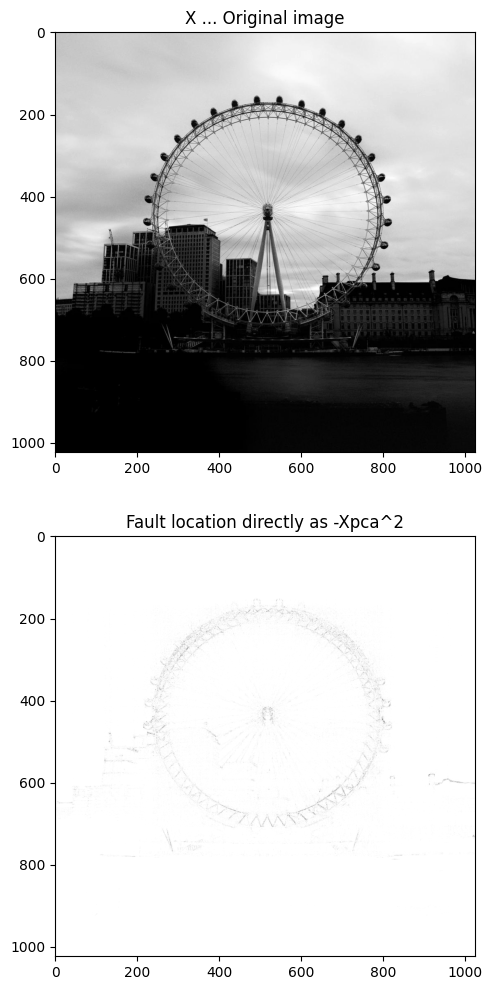

In [9]:

X = im1.copy()
X = (X - np.mean(X)) / np.std(X)

# Calculate the covariance matrix (M x M)
covX = np.dot(X.T, X)

# Eigenvalues and eigenvectors
d, Vcols = np.linalg.eig(covX)

print("X ... N x M =",X.shape)

m = 50

# Project the data onto the first 'm' columns of Vcols
Xcols = np.dot(X, Vcols[:, m:])

# Project the data along the columns to get 'Xrows'
Xrows = Xcols.T

# Calculate the covariance matrix (N x N) for 'Xrows'
covX = np.dot(Xrows.T, Xrows)

# Eigenvalues and eigenvectors for 'Xrows'
d, Vrows = np.linalg.eig(covX)

# Define the value 'n'
n = 50

# Compress the image to 'n' rows and 'm' columns
Xcompressed = np.dot(Xrows, Vrows[:, n:])

# Perform the decompression
Xpca_rows = np.dot(Xcompressed, Vrows[:, n:].T)
Xpca_cols = Xpca_rows.T
Xpca = np.dot(Xpca_cols, Vcols[:, m:].T)
Xpca = np.real(Xpca)

# Create a figure for visualization
plt.figure(figsize=(10, 12))
plt.subplot(211)
plt.title("X ... Original image")
plt.imshow(X, cmap='gray')
plt.subplot(212)
plt.imshow(-Xpca**2, cmap='gray')
plt.title("Fault location directly as -Xpca^2")
plt.show()

X ... N x M = (1024, 1024)


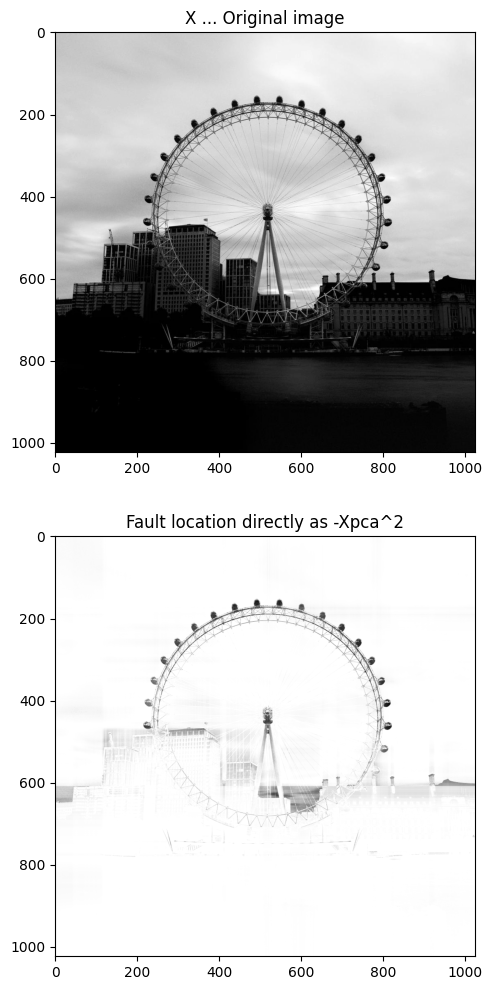

In [10]:
X = im1.copy()
X = (X - np.mean(X)) / np.std(X)

# Calculate the covariance matrix (M x M)
covX = np.dot(X.T, X)

# Eigenvalues and eigenvectors
d, Vcols = np.linalg.eig(covX)

print("X ... N x M =",X.shape)

m = 1

# Project the data onto the first 'm' columns of Vcols
Xcols = np.dot(X, Vcols[:, m:])

# Project the data along the columns to get 'Xrows'
Xrows = Xcols.T

# Calculate the covariance matrix (N x N) for 'Xrows'
covX = np.dot(Xrows.T, Xrows)

# Eigenvalues and eigenvectors for 'Xrows'
d, Vrows = np.linalg.eig(covX)

# Define the value 'n'
n = 1

# Compress the image to 'n' rows and 'm' columns
Xcompressed = np.dot(Xrows, Vrows[:, n:])

# Perform the decompression
Xpca_rows = np.dot(Xcompressed, Vrows[:, n:].T)
Xpca_cols = Xpca_rows.T
Xpca = np.dot(Xpca_cols, Vcols[:, m:].T)
Xpca = np.real(Xpca)

# Create a figure for visualization
plt.figure(figsize=(10, 12))
plt.subplot(211)
plt.title("X ... Original image")
plt.imshow(X, cmap='gray')
plt.subplot(212)
plt.imshow(-Xpca**2, cmap='gray')
plt.title("Fault location directly as -Xpca^2")
plt.show()

The selection of eigenvectors plays a crucial role in the effectiveness of anomaly detection. Choosing too few eigenvectors may result in only a limited portion of the data's variance being represented, which can lead to the omission of essential information. This inadequacy makes it challenging to distinguish between normal and anomalous data points.

On the other hand, selecting too many eigenvectors can introduce noise into the model. This situation may lead to overfitting, where the model learns random noise instead of the underlying structure of the data. Consequently, normal data points could be incorrectly identified as anomalies due to these random variations.

<div style="width:100%;height:3px;background-color:green"> </div>

#### Odkazy:

https://numpy.org/doc/1.18/reference/generated/numpy.corrcoef.html

Image tutorial — Matplotlib 3.2.1 documentation [online]. [vid. 2020-06-14]. Dostupné z: https://matplotlib.org/tutorials/introductory/images.html

Image Module — Pillow (PIL Fork) 7.1.2 documentation [online]. [vid. 2020-06-14]. Dostupné z: https://pillow.readthedocs.io/en/stable/reference/Image.html

https://ch.mathworks.com/help/matlab/ref/corrcoef.html

https://stackoverflow.com/questions/58174390/how-to-detect-image-translation-with-only-numpy-and-pil

Šípek Vojtěch:VYUŽITÍ OBRAZOVÉ ANALÝZY A JEJÍCH ALGORITMŮ PŘI DEFEKTOSKOPII NANOVLÁKENNÝCH VRSTEV, Diplomová práce, FS ČVUT v Praze,2019-02-05, https://dspace.cvut.cz/handle/10467/80564